# Sprint - 2 Probability Distributions

# 06_Probability_Distributions

### What are Probability Distributions?

A probability distribution describes how the probabilities of a random variable's possible values are spread out. Discrete distributions (like Bernoulli, Binomial, Poisson) assign probabilities to countable outcomes, while continuous distributions (like Uniform, Normal, Exponential) use a density function over a continuous range. Choosing the right distribution to model a process — a single trial, a count of events, or a waiting time — is fundamental to statistics and underlies core AI/ML techniques like Naive Bayes, logistic regression, weight initialization, and survival analysis.

## 01. Bernoulli Distribution

**Definition**: A discrete distribution describing a single trial with exactly two possible outcomes — success (1) with probability p, or failure (0) with probability 1−p.

**Formula**: P(X = x) = pˣ (1−p)⁽¹⁻ˣ⁾, for x ∈ {0, 1}

**Where it is used**: Modeling any single yes/no, true/false, or success/failure trial. It's the building block for the Binomial distribution (n Bernoulli trials) and for binary classification outputs.

**Real-World Example**: A single flip of a biased coin — heads (1) with probability p, tails (0) with probability 1−p.

**AI/ML Example**: The label in binary classification (e.g., "spam" vs "not spam" for one email) is modeled as a Bernoulli random variable; Bernoulli Naive Bayes uses this distribution for binary feature values.

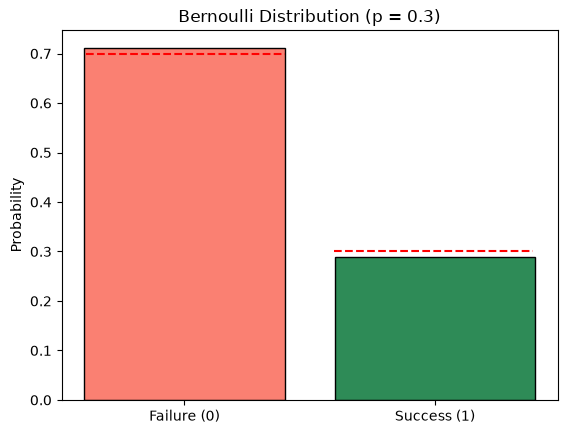

Empirical P(Success): 0.2887 | Theoretical: 0.3


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
p = 0.3
trials = np.random.binomial(1, p, size=10000)  # Bernoulli = Binomial with n=1

values, counts = np.unique(trials, return_counts=True)
probs = counts / len(trials)

plt.bar(values, probs, tick_label=["Failure (0)", "Success (1)"], edgecolor="black", color=["salmon", "seagreen"])
plt.axhline(1 - p, xmin=0.05, xmax=0.45, color="red", linestyle="--")
plt.axhline(p, xmin=0.55, xmax=0.95, color="red", linestyle="--")
plt.title(f"Bernoulli Distribution (p = {p})")
plt.ylabel("Probability")
plt.show()

print("Empirical P(Success):", round(probs[1], 4), "| Theoretical:", p)

### Interpretation:
The bar heights closely match the theoretical probabilities p and 1−p, confirming the simulated trials follow a Bernoulli(p) distribution with only two possible outcomes.

### Advantages:
- Simplest possible probability model — easy to interpret and compute with.
- Forms the foundation for more complex distributions (Binomial) and binary ML models.

### Limitations:
- Only models a single trial; can't describe repeated trials or counts on its own.
- Not suitable when outcomes have more than two possible categories.

## 02. Binomial Distribution

**Definition**: A discrete distribution giving the probability of exactly k successes in n independent Bernoulli trials, each with the same success probability p.

**Formula**: P(X = k) = C(n, k) · pᵏ · (1−p)⁽ⁿ⁻ᵏ⁾, where C(n, k) = n! / [k!(n−k)!]

**Where it is used**: Modeling the count of successes across a fixed number of independent, identical trials — quality control, survey sampling, and repeated experiments.

**Real-World Example**: The number of heads obtained in 10 flips of a fair coin.

**AI/ML Example**: In A/B testing, the number of conversions out of n visitors shown a variant is modeled as Binomial, used to test statistical significance between variants.

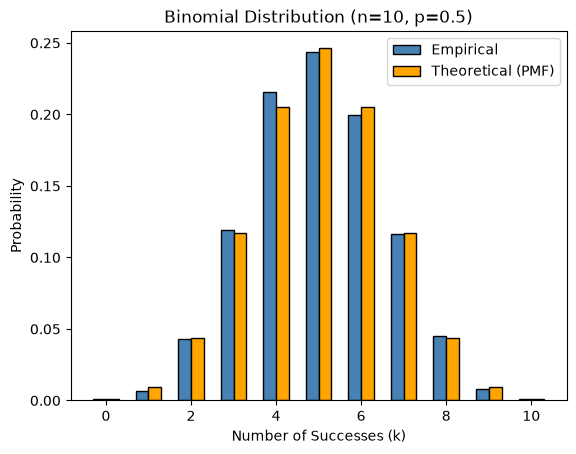

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n, p = 10, 0.5
np.random.seed(3)
samples = np.random.binomial(n, p, size=10000)

values, counts = np.unique(samples, return_counts=True)
empirical_probs = counts / len(samples)
k = np.arange(0, n + 1)
theoretical_probs = binom.pmf(k, n, p)

plt.bar(values - 0.15, empirical_probs, width=0.3, label="Empirical", color="steelblue", edgecolor="black")
plt.bar(k + 0.15, theoretical_probs, width=0.3, label="Theoretical (PMF)", color="orange", edgecolor="black")
plt.title(f"Binomial Distribution (n={n}, p={p})")
plt.xlabel("Number of Successes (k)")
plt.ylabel("Probability")
plt.legend()
plt.show()

### Interpretation:
The empirical distribution of successes closely follows the theoretical Binomial PMF, peaking around k=5 (n·p), the expected number of successes for 10 fair coin flips.

### Advantages:
- Models repeated independent trials with a clear, closed-form formula.
- Widely applicable to quality control, surveys, and hypothesis testing (e.g., A/B tests).

### Limitations:
- Assumes trials are independent and identically distributed (same p every time) — invalid if p changes or trials are correlated.
- Becomes computationally awkward for very large n without approximations (e.g., Normal approximation).

## 03. Poisson Distribution

**Definition**: A discrete distribution modeling the number of events occurring in a fixed interval of time or space, given a known constant average rate (λ) and independent events.

**Formula**: P(X = k) = (λᵏ · e⁻λ) / k!

**Where it is used**: Modeling rare or count-based events over a fixed interval — customer arrivals, system failures, network traffic, defect counts.

**Real-World Example**: The number of customers arriving at a store between 2 PM and 3 PM, given an average rate of 4 customers per hour.

**AI/ML Example**: Poisson regression models count-based targets (e.g., predicted number of clicks, support tickets, or claims); Poisson assumptions also appear in anomaly detection for rare-event rates.

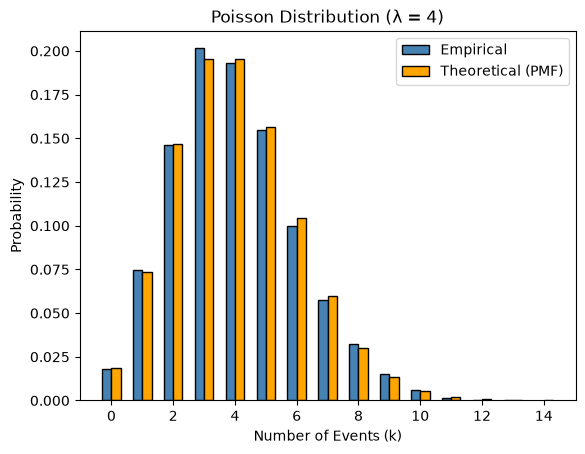

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

lam = 4
np.random.seed(6)
samples = np.random.poisson(lam, size=10000)

values, counts = np.unique(samples, return_counts=True)
empirical_probs = counts / len(samples)
k = np.arange(0, 15)
theoretical_probs = poisson.pmf(k, lam)

plt.bar(values - 0.15, empirical_probs, width=0.3, label="Empirical", color="steelblue", edgecolor="black")
plt.bar(k + 0.15, theoretical_probs, width=0.3, label="Theoretical (PMF)", color="orange", edgecolor="black")
plt.title(f"Poisson Distribution (λ = {lam})")
plt.xlabel("Number of Events (k)")
plt.ylabel("Probability")
plt.legend()
plt.show()

### Interpretation:
The simulated event counts closely track the theoretical Poisson PMF, with the distribution peaking near λ=4 and showing the characteristic right-skew of count data.

### Advantages:
- Requires only one parameter (λ), making it simple to fit and interpret.
- Well-suited for modeling rare, independent events over time or space.

### Limitations:
- Assumes the event rate λ is constant and events are independent — violated by bursty or seasonal patterns.
- Assumes mean equals variance; real count data is often "over-dispersed" (variance > mean), requiring alternatives like Negative Binomial.

## 04. Uniform Distribution

**Definition**: A continuous distribution where every value within a defined range [a, b] is equally likely to occur — a "flat" distribution.

**Formula**: f(x) = 1 / (b − a), for a ≤ x ≤ b

**Where it is used**: Modeling complete randomness with no bias toward any value; also used for random number generation and simulations.

**Real-World Example**: The waiting time (in minutes) for a bus that arrives randomly and uniformly at any point within a 10-minute window.

**AI/ML Example**: Neural network weight initialization often draws from a Uniform distribution (e.g., Xavier/Glorot uniform initialization) to break symmetry between neurons.

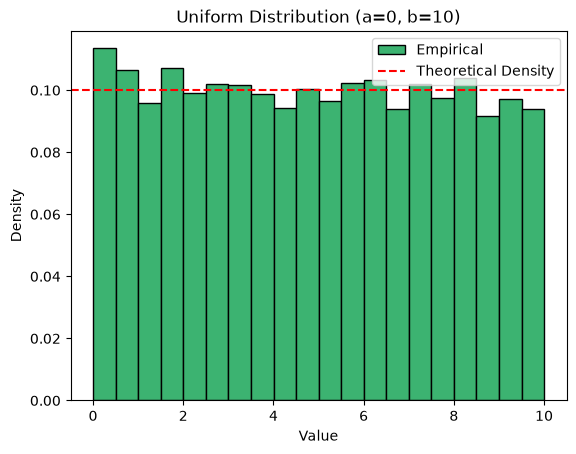

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)
a, b = 0, 10
samples = np.random.uniform(a, b, size=10000)

plt.hist(samples, bins=20, density=True, edgecolor="black", color="mediumseagreen", label="Empirical")
plt.axhline(1 / (b - a), color="red", linestyle="--", label="Theoretical Density")
plt.title(f"Uniform Distribution (a={a}, b={b})")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

### Interpretation:
The histogram bars are roughly the same height across the entire range, confirming that no value between a and b is more likely than another — matching the flat theoretical density.

### Advantages:
- Simple to understand, simulate, and sample from.
- Ideal baseline for modeling "no prior preference" scenarios or initializing randomness.

### Limitations:
- Rarely reflects real-world phenomena, which usually cluster around some central value.
- Sensitive to correctly bounding [a, b]; an incorrect range misrepresents the true process.

## 05. Normal Distribution

**Definition**: A continuous, symmetric distribution where values cluster around a mean, with frequency decreasing gradually in both directions, forming the classic "bell curve."

**Formula**: f(x) = (1 / (σ√(2π))) × e^(−(x − μ)² / (2σ²))

**Where it is used**: Statistical inference, hypothesis testing, and any process where the Central Limit Theorem applies — sample means, measurement errors, natural biological/physical measurements.

**Real-World Example**: Heights of adult men in a population tend to follow a Normal distribution.

**AI/ML Example**: Linear regression assumes normally distributed residuals; weight initialization (Normal/Gaussian init) and Gaussian Naive Bayes both rely directly on this distribution.

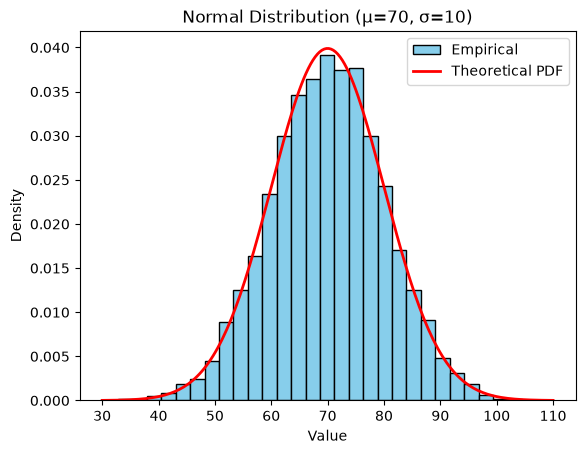

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 70, 10
np.random.seed(15)
samples = np.random.normal(mu, sigma, size=10000)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
pdf = norm.pdf(x, mu, sigma)

plt.hist(samples, bins=30, density=True, edgecolor="black", color="skyblue", label="Empirical")
plt.plot(x, pdf, color="red", linewidth=2, label="Theoretical PDF")
plt.title(f"Normal Distribution (μ={mu}, σ={sigma})")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

### Interpretation:
The histogram forms the expected bell-shaped curve centered at μ=70, closely matching the theoretical Normal PDF overlaid in red.

### Advantages:
- Fully described by just two parameters (mean and standard deviation).
- Underlies most classical statistical tests and many ML algorithms via the Central Limit Theorem.

### Limitations:
- Real-world data is often not perfectly normal (skewed or heavy-tailed).
- Assuming normality when it doesn't hold can produce invalid confidence intervals or biased model estimates.
    

## 06. Exponential Distribution

**Definition**: A continuous distribution modeling the time between independent events that occur at a constant average rate (i.e., the waiting time in a Poisson process). It is "memoryless" — the probability of waiting longer doesn't depend on time already elapsed.

**Formula**: f(x) = λ · e^(−λx), for x ≥ 0

**Where it is used**: Modeling waiting times or time-to-event data — time until the next customer arrival, time until equipment failure, or time between server requests.

**Real-World Example**: The time between successive customer arrivals at a store, given an average arrival rate.

**AI/ML Example**: Survival analysis and churn modeling use the Exponential distribution (or its generalizations) to model "time until an event" such as a customer canceling a subscription or a machine failing.

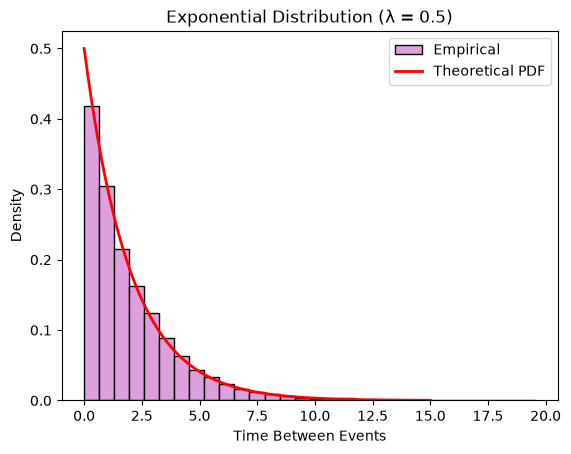

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

lam = 0.5   # rate parameter
scale = 1 / lam
np.random.seed(20)
samples = np.random.exponential(scale, size=10000)

x = np.linspace(0, 15, 200)
pdf = expon.pdf(x, scale=scale)

plt.hist(samples, bins=30, density=True, edgecolor="black", color="plum", label="Empirical")
plt.plot(x, pdf, color="red", linewidth=2, label="Theoretical PDF")
plt.title(f"Exponential Distribution (λ = {lam})")
plt.xlabel("Time Between Events")
plt.ylabel("Density")
plt.legend()
plt.show()

### Interpretation:
The histogram shows a sharp peak near zero with a long right tail, matching the theoretical Exponential PDF — most waiting times are short, but occasionally much longer waits occur.

### Advantages:
- Simple one-parameter model (λ) for time-to-event data.
- The memoryless property simplifies reliability and queueing calculations.

### Limitations:
- The memoryless assumption is unrealistic for processes where "wear and tear" increases failure risk over time (better modeled by Weibull distribution).
- Only models a single event rate; can't capture multi-stage or seasonal event processes.

## Interview Questions and Answers

**1. What is the key difference between Bernoulli and Binomial distributions?**
Bernoulli models a single trial with two outcomes; Binomial models the number of successes across n independent Bernoulli trials with the same success probability p.

**2. When would you use a Poisson distribution instead of a Binomial distribution?**
Poisson is used when counting events over a continuous interval (time/space) with a known average rate and no fixed "number of trials," whereas Binomial requires a fixed, known number of discrete trials.

**3. What does it mean for the Exponential distribution to be "memoryless"?**
The probability of waiting an additional amount of time is independent of how much time has already elapsed — e.g., the chance of waiting 5 more minutes for a bus is the same whether you've already waited 0 or 20 minutes.

**4. Why is the Normal distribution so central to statistics and machine learning?**
Due to the Central Limit Theorem, the sampling distribution of the mean of many independent random variables approaches Normal regardless of the original distribution, making it foundational for inference, confidence intervals, and many model assumptions.

**5. How is the Uniform distribution used in practice for AI/ML?**
It's commonly used for neural network weight initialization (e.g., Xavier/Glorot uniform) and for generating random samples with no bias in simulations or Monte Carlo methods.

**6. What assumption of the Poisson distribution is often violated in real data, and what's the alternative?**
It assumes the mean equals the variance; real count data is often "over-dispersed" (variance > mean), in which case the Negative Binomial distribution is a better fit.

**7. How are Bernoulli and Binomial distributions relevant to binary classification?**
Bernoulli Naive Bayes directly models binary features/labels as Bernoulli random variables; the Binomial distribution is used in A/B testing to compare conversion counts between binary-outcome experiment groups.

**8. What real-world process would you model with the Exponential distribution rather than the Normal distribution?**
Time-to-event data with a constant hazard rate — like time until a server crashes or time between customer arrivals — since these are non-negative, right-skewed, and memoryless, unlike the symmetric, unbounded Normal distribution.

## Self Reflection

Working through these six distributions highlighted how the *type of question being asked* determines the right distribution to use:
- **Bernoulli and Binomial** answer "how many successes?" in discrete, fixed-trial settings — the backbone of classification and A/B testing.
- **Poisson** answers "how many events in this interval?" for rare, rate-based occurrences.
- **Uniform** answers "is any outcome equally likely?" — useful for pure randomness and initialization.
- **Normal** answers "what's typical, and how much does it vary?" — the default assumption behind countless statistical and ML methods thanks to the Central Limit Theorem.
- **Exponential** answers "how long until the next event?" — essential for reliability, queuing, and survival/churn analysis.

Together, these distributions form a toolkit: discrete ones (Bernoulli, Binomial, Poisson) count events, while continuous ones (Uniform, Normal, Exponential) measure magnitudes or durations. Matching the right distribution to the right real-world process is what makes downstream statistical tests and ML models trustworthy.